### ModelCheckpoint() 최적의 알고리즘을 찾아 저장(완성된 모델)된 모델을 호출해서 학습(load_model()함수)

In [1]:
from tensorflow import keras

In [ ]:
# 저장된 모델 호출
# ModelCheckpoint() 
# save_best_only=True
model = keras.models.load_model('best-cnn-model.h5')

In [4]:
model.layers

[<Conv2D name=conv2d, built=True>,
 <MaxPooling2D name=max_pooling2d, built=True>,
 <Conv2D name=conv2d_1, built=True>,
 <MaxPooling2D name=max_pooling2d_1, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>]

In [5]:
conv = model.layers[0]
print(conv.weights[0].shape, conv.weights[1].shape)

(3, 3, 1, 32) (32,)


In [6]:
import numpy

conv_weights = conv.weights[0].numpy()
print(conv_weights.mean(), conv_weights.std())

-0.061427608 0.39392945


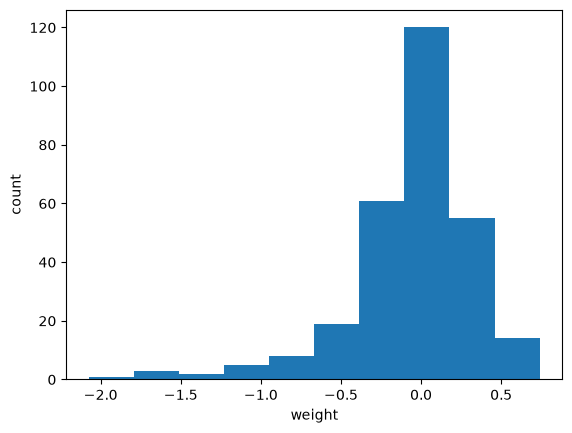

In [7]:
import os
import matplotlib.pyplot as plt

os.environ['KMP_DUPLICATION_LIB_OK'] = 'True'

plt.hist(conv_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

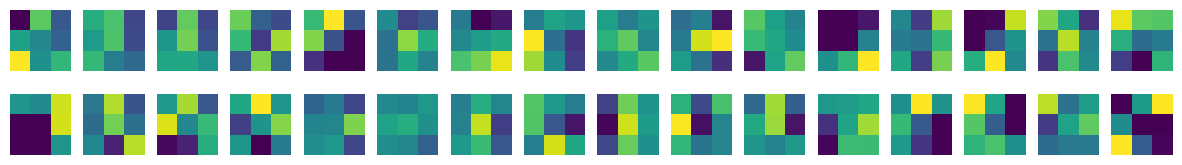

In [ ]:
fig, axs = plt.subplots(2, 16, figsize=(15, 2))

for i in range(2):
    for j in range(16):
        axs[i, j].imshow(conv_weights[:, :, 0, i*16+j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
        
plt.show()

# 학습이된 데이터는 고유 데이터는 구별점이 시각화되어 출력(색상 구별)

In [9]:
no_training_model = keras.Sequential()

# 학습 시키지 않은 모델
# Conv2D 레이어 추가
no_training_model.add(keras.Input(shape=(28, 28, 1)))
no_training_model.add(
    keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding='same',
        strides=1,
        activation='relu'
    )
)

In [ ]:
no_training_conv = no_training_model.layers[0]
print(no_training_conv.weights[0].shape)

# 3차원 출력

(3, 3, 1, 32)


In [11]:
no_training_weights = no_training_conv.weights[0].numpy()
print(no_training_weights.mean(), no_training_weights.std())

0.0049416963 0.077797286


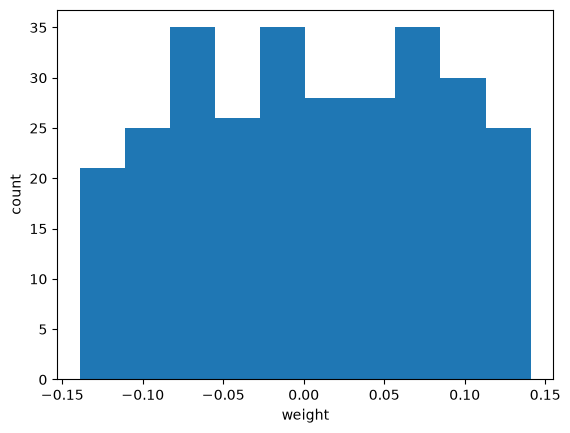

In [12]:
plt.hist(no_training_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

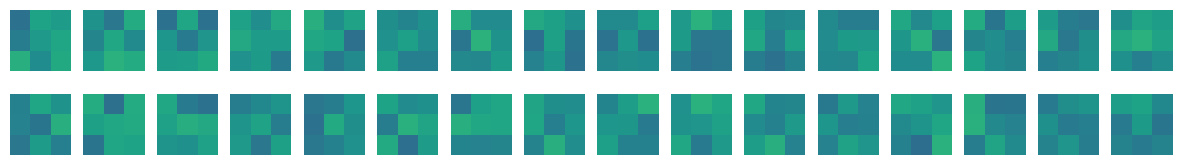

In [ ]:
fig, axs = plt.subplots(2, 16, figsize=(15, 2))

for i in range(2):
    for j in range(16):
        axs[i, j].imshow(no_training_weights[:, :, 0, i*16+j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
        
plt.show()

# 학습이 되어지지 않은 데이터는 고유 데이터는 구별점 없이 출력, 색상이 동일